# Phase 3 — Model A: MLP (Multi-Layer Perceptron)
## Blood Vessel Blockage Detection Project

**What is MLP?**
- MLP = Multi-Layer Perceptron — sabse basic deep learning model
- Fully connected layers — har neuron doosre se connected hota hai
- Tabular data ke liye BEST deep learning model

**Architecture:**
```
Input (15) → Dense(128) → Dropout → Dense(64) → Dropout → Dense(32) → Dense(1)
```

**Key Concepts:**
- **ReLU Activation** — non-linearity add karta hai
- **Dropout** — overfitting rokta hai
- **Adam Optimizer** — smart learning rate
- **Binary Cross Entropy** — classification loss

In [ ]:
from google.colab import files
read = files.upload()

Saving phase2_labeled_data (1).csv to phase2_labeled_data (1).csv


In [ ]:
# Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)

print('All libraries imported!')

All libraries imported!


---
## Step 1 — Load Phase 2 Labeled Data

In [ ]:
df = pd.read_csv('phase2_labeled_data (1).csv')
print('Shape:', df.shape)
df.head()

Shape: (2000, 19)


,peak_systolic_velocity,resistive_index,blood_flow_velocity,avg_temperature,temperature_difference,cold_spot_area_percent,heart_rate,pulse_amplitude,pulse_transit_time,hrv,velocity_ratio,thermal_stress,cardiac_load,vascular_resistance,flow_efficiency,blockage_score,blockage_label,confidence,risk_level
0,83.085284,0.696231,96.250183,36.574682,2.407925,6.796991,69.0,2.298226,0.196088,48.0,0.863222,16.366643,158.577612,0.136523,1.394930,0,0,High,Low Risk
1,129.254272,0.853361,64.919065,35.725150,3.708868,20.324207,113.0,0.840300,0.288642,24.0,1.991006,75.379801,94.953946,0.246316,0.574505,12,1,High,Critical Risk
2,105.756839,0.836293,64.084861,35.936101,4.405234,10.418063,86.0,1.151399,0.293710,56.0,1.650262,45.894002,99.020324,0.245627,0.745173,7,1,Medium,Critical Risk
3,133.971340,0.688480,69.625238,36.118859,3.347995,8.783595,94.0,1.752332,0.278041,50.0,1.924178,29.407435,164.719245,0.191426,0.740694,4,1,Low,High Risk
4,105.756839,0.696231,70.038666,36.995431,2.841834,5.616955,61.0,1.725171,0.212553,78.0,1.509978,15.962453,105.235446,0.147986,1.148175,0,0,High,Low Risk


In [ ]:
# Separate features and labels
feature_cols = [c for c in df.columns
                if c not in ['blockage_score','blockage_label','confidence','risk_level']]

X = df[feature_cols].values.astype(np.float64)
y = df['blockage_label'].values.astype(np.float64)

print('X shape:', X.shape)
print('y shape:', y.shape)
print('Normal patients  :', (y==0).sum())
print('Blockage patients:', (y==1).sum())

X shape: (2000, 15)
y shape: (2000,)
Normal patients  : 1153
Blockage patients: 847


---
## Step 2 — Train / Validation / Test Split

**Why 70 / 15 / 15 split?**
- **Train (70%)** → Model yahan se seekhta hai
- **Validation (15%)** → Training ke dauran check karo — overfitting toh nahi?
- **Test (15%)** → Final unbiased evaluation — model ne kabhi yeh data nahi dekha

**Stratified Split kyu?**
- Normal: 57.7%, Blockage: 42.3%
- Stratified = yahi ratio teeno splits mein maintain hoga

In [ ]:
# Scale features first
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split: 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.30, random_state=42, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print('Train size :', X_train.shape, '| Blockage%:', round(y_train.mean()*100,1))
print('Val   size :', X_val.shape,   '| Blockage%:', round(y_val.mean()*100,1))
print('Test  size :', X_test.shape,  '| Blockage%:', round(y_test.mean()*100,1))

Train size : (1400, 15) | Blockage%: 42.4
Val   size : (300, 15) | Blockage%: 42.3
Test  size : (300, 15) | Blockage%: 42.3


---
## Step 3 — MLP Architecture

**Layer by Layer explanation:**

```
Input Layer  : 15 neurons  (15 features)
     ↓
Dense(128)   : 128 neurons + ReLU  — complex patterns seekhta hai
Dropout(0.3) : 30% neurons randomly off — overfitting rokta hai
     ↓
Dense(64)    : 64 neurons + ReLU   — features compress karta hai
Dropout(0.2) : 20% neurons randomly off
     ↓
Dense(32)    : 32 neurons + ReLU   — final pattern extraction
     ↓
Dense(1)     : 1 neuron + Sigmoid  — 0 to 1 probability output
```

**Sigmoid output:**
- Output > 0.5 = Blockage
- Output ≤ 0.5 = Normal

In [ ]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(15,)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

---
## Step 4 — Train MLP Model

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibility
tf.random.set_seed(42)

# Build MLP
model = Sequential([
    Dense(128, activation='relu', input_shape=(15,)),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.2),

    Dense(32, activation='relu'),

    Dense(1, activation='sigmoid')
])

# Compile Model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

print("Training MLP...")
print("="*70)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

print("="*70)
print("Training Complete!")

Training MLP...
Epoch 1/150
44/44 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.8800 - loss: 0.3373 - val_accuracy: 0.9200 - val_loss: 0.1520
Epoch 2/150
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9264 - loss: 0.1495 - val_accuracy: 0.9467 - val_loss: 0.1167
Epoch 3/150
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9436 - loss: 0.1317 - val_accuracy: 0.9533 - val_loss: 0.0972
Epoch 4/150
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9507 - loss: 0.1170 - val_accuracy: 0.9600 - val_loss: 0.0880
Epoch 5/150
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9514 - loss: 0.1087 - val_accuracy: 0.9633 - val_loss: 0.0820
Epoch 6/150
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9607 - loss: 0.1003 - val_accuracy: 0.9633 - val_loss: 0.0790
Epoch 7/150
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9550 - loss: 0.1013 - val_accuracy: 0.9600 - val_loss: 0.0764
Epoch 8/150
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9614 - loss: 0.0981 - val_a

---
## Step 5 — Training Curves

**What to look for:**
- Train loss aur Val loss dono neeche jaayein → Model sikh raha hai ✅
- Train loss neeche, Val loss upar → Overfitting ⚠️
- Dono zyada upar → Underfitting ⚠️

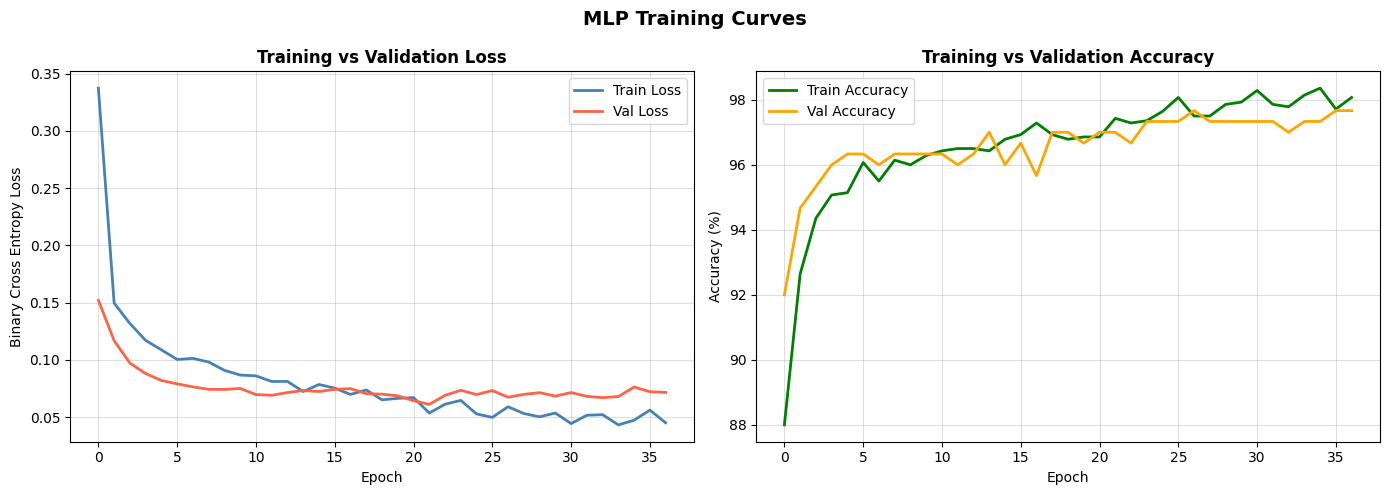

In [ ]:
# Loss curves (TensorFlow/Keras)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'],
             label='Train Loss',
             color='steelblue',
             linewidth=2)

axes[0].plot(history.history['val_loss'],
             label='Val Loss',
             color='tomato',
             linewidth=2)

axes[0].set_title('Training vs Validation Loss', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Cross Entropy Loss')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.4)

# Accuracy
axes[1].plot([a * 100 for a in history.history['accuracy']],
             label='Train Accuracy',
             color='green',
             linewidth=2)

axes[1].plot([a * 100 for a in history.history['val_accuracy']],
             label='Val Accuracy',
             color='orange',
             linewidth=2)

axes[1].set_title('Training vs Validation Accuracy', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.4)

plt.suptitle('MLP Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 6 — Test Set Evaluation

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Predict probabilities
y_prob = model.predict(X_test, verbose=0).flatten()

# Convert probabilities to class labels
y_pred = (y_prob > 0.5).astype(int)

# Metrics
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_prob)

print('MLP TEST SET RESULTS')
print('='*40)
print(f'Accuracy  : {acc*100:.2f}%')
print(f'Precision : {prec*100:.2f}%')
print(f'Recall    : {rec*100:.2f}%')
print(f'F1-Score  : {f1*100:.2f}%')
print(f'ROC-AUC   : {auc:.4f}')
print('='*40)



MLP TEST SET RESULTS
Accuracy  : 95.67%
Precision : 95.24%
Recall    : 94.49%
F1-Score  : 94.86%
ROC-AUC   : 0.9944


In [ ]:
from sklearn.metrics import classification_report

print("CLASSIFICATION REPORT")
print("="*50)

print(classification_report(
    y_test,
    y_pred,
    target_names=['Normal', 'Blockage'],
    digits=4
))

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Normal     0.9598    0.9653    0.9625       173
    Blockage     0.9524    0.9449    0.9486       127

    accuracy                         0.9567       300
   macro avg     0.9561    0.9551    0.9556       300
weighted avg     0.9566    0.9567    0.9566       300



---
## Step 7 — Confusion Matrix

**Reading Confusion Matrix:**
```
                Predicted Normal  |  Predicted Blockage
Actual Normal        TN           |       FP  (False Alarm)
Actual Blockage      FN (Missed!) |       TP
```
- **Medical mein FN (Missed Blockage) most dangerous hai!**
- Isliye Recall important hai — kitne real blockage pakde

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Blockage'],
            yticklabels=['Normal', 'Blockage'],
            linewidths=2, linecolor='white',
            annot_kws={'size': 18, 'weight': 'bold'})
plt.title('MLP — Confusion Matrix', fontsize=13, fontweight='bold')
plt.ylabel('Actual Label', fontsize=11)
plt.xlabel('Predicted Label', fontsize=11)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True  Normal   (TN): {tn}')
print(f'False Alarm    (FP): {fp}')
print(f'Missed Blockage(FN): {fn}')
print(f'True  Blockage (TP): {tp}')

---
## Step 8 — ROC Curve

**What is ROC Curve?**
- ROC = Receiver Operating Characteristic
- X-axis = False Positive Rate (Normal patients jo galat flag hue)
- Y-axis = True Positive Rate / Recall (Real blockage jo pakde)
- **AUC (Area Under Curve) closer to 1.0 = better model**
- AUC = 0.5 = Random guessing (useless model)

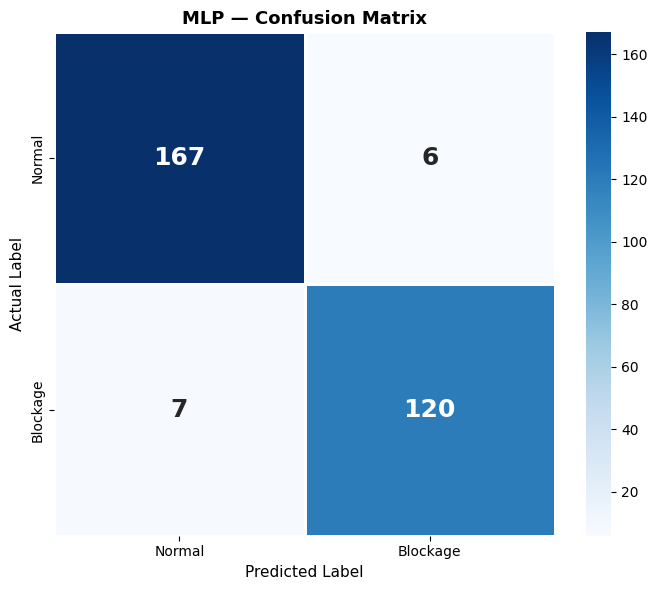

True Normal (TN)     : 167
False Alarm (FP)     : 6
Missed Blockage (FN) : 7
True Blockage (TP)   : 120


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions
y_prob = model.predict(X_test, verbose=0).flatten()
y_pred = (y_prob > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal', 'Blockage'],
    yticklabels=['Normal', 'Blockage'],
    linewidths=2,
    linecolor='white',
    annot_kws={'size': 18, 'weight': 'bold'}
)

plt.title('MLP — Confusion Matrix', fontsize=13, fontweight='bold')
plt.ylabel('Actual Label', fontsize=11)
plt.xlabel('Predicted Label', fontsize=11)
plt.tight_layout()
plt.show()

# Extract values
tn, fp, fn, tp = cm.ravel()

print(f'True Normal (TN)     : {tn}')
print(f'False Alarm (FP)     : {fp}')
print(f'Missed Blockage (FN) : {fn}')
print(f'True Blockage (TP)   : {tp}')

---
## Step 9 — Prediction Probability Distribution

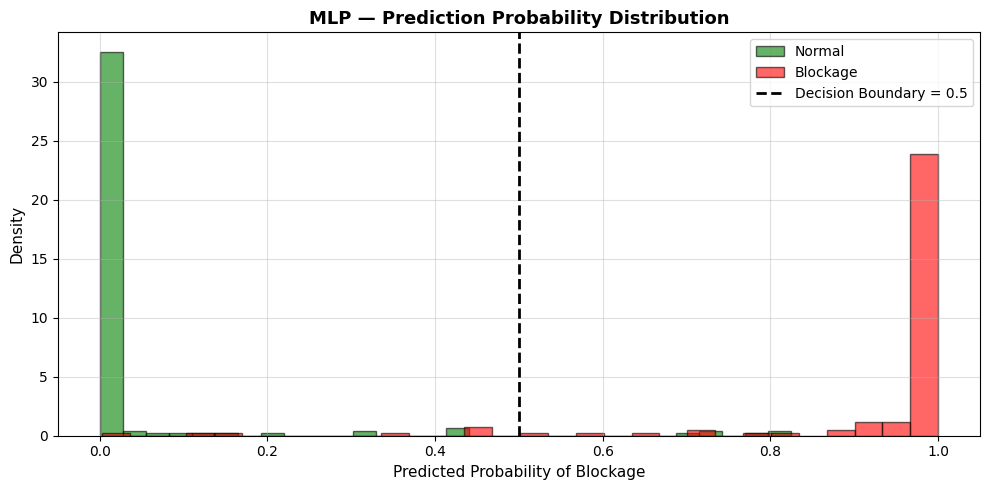

In [ ]:
# Predict probabilities
y_prob = model.predict(X_test, verbose=0).flatten()

# Probability distribution — Normal vs Blockage
prob_normal   = y_prob[y_test == 0]
prob_blockage = y_prob[y_test == 1]

plt.figure(figsize=(10, 5))

plt.hist(
    prob_normal,
    bins=30,
    alpha=0.6,
    color='green',
    label='Normal',
    density=True,
    edgecolor='black'
)

plt.hist(
    prob_blockage,
    bins=30,
    alpha=0.6,
    color='red',
    label='Blockage',
    density=True,
    edgecolor='black'
)

plt.axvline(
    0.5,
    color='black',
    linestyle='--',
    linewidth=2,
    label='Decision Boundary = 0.5'
)

plt.xlabel('Predicted Probability of Blockage', fontsize=11)
plt.ylabel('Density', fontsize=11)
plt.title('MLP — Prediction Probability Distribution', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

---
## Step 10 — Performance Metrics Bar Chart

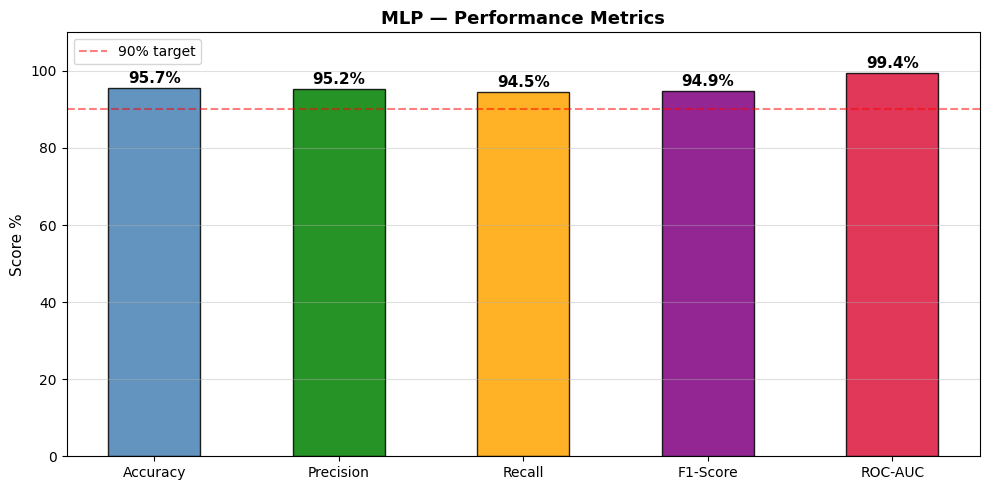

In [ ]:
# Metrics visualization

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
values  = [acc, prec, rec, f1, auc]
colors  = ['steelblue', 'green', 'orange', 'purple', 'crimson']

plt.figure(figsize=(10, 5))

bars = plt.bar(
    metrics,
    [v * 100 for v in values],
    color=colors,
    edgecolor='black',
    alpha=0.85,
    width=0.5
)

for bar, val in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{val*100:.1f}%',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.ylim(0, 110)
plt.axhline(
    90,
    color='red',
    linestyle='--',
    alpha=0.5,
    label='90% target'
)

plt.ylabel('Score %', fontsize=11)
plt.title('MLP — Performance Metrics', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

---
## Step 11 — K-Fold Cross Validation

**Why K-Fold?**
- Ek baar ka train-test split lucky/unlucky ho sakta hai
- K-Fold = 5 baar alag alag split pe train karo
- Average accuracy = model ki TRUE performance
- Variance = model kitna stable hai

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import tensorflow as tf
import numpy as np

print('Running 5-Fold Cross Validation...')
print('='*55)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_accs, fold_f1s, fold_aucs = [], [], []

X_all = np.vstack([X_train, X_val, X_test])
y_all = np.concatenate([y_train, y_val, y_test])

for fold, (train_idx, val_idx) in enumerate(skf.split(X_all, y_all)):

    Xtr, Xvl = X_all[train_idx], X_all[val_idx]
    ytr, yvl = y_all[train_idx], y_all[val_idx]

    # Scale per fold
    sc = StandardScaler()
    Xtr = sc.fit_transform(Xtr)
    Xvl = sc.transform(Xvl)

    tf.random.set_seed(42 + fold)

    # Build Model
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(128, activation='relu', input_shape=(15,)),
        tf.keras.layers.Dropout(0.3),

        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.2),

        tf.keras.layers.Dense(32, activation='relu'),

        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    # Quick Training
    model.fit(
        Xtr,
        ytr,
        epochs=50,
        batch_size=32,
        verbose=0
    )

    # Predictions
    yprob = model.predict(Xvl, verbose=0).flatten()
    yp = (yprob > 0.5).astype(int)

    fa   = accuracy_score(yvl, yp)
    ff   = f1_score(yvl, yp)
    fauc = roc_auc_score(yvl, yprob)

    fold_accs.append(fa)
    fold_f1s.append(ff)
    fold_aucs.append(fauc)

    print(f'  Fold {fold+1} → Accuracy: {fa*100:.1f}% | F1: {ff*100:.1f}% | AUC: {fauc:.3f}')

print('='*55)
print(f'  Mean Accuracy : {np.mean(fold_accs)*100:.2f}% ± {np.std(fold_accs)*100:.2f}%')
print(f'  Mean F1-Score : {np.mean(fold_f1s)*100:.2f}% ± {np.std(fold_f1s)*100:.2f}%')
print(f'  Mean AUC      : {np.mean(fold_aucs):.3f} ± {np.std(fold_aucs):.3f}')

Running 5-Fold Cross Validation...
  Fold 1 → Accuracy: 95.8% | F1: 95.1% | AUC: 0.994
  Fold 2 → Accuracy: 97.8% | F1: 97.4% | AUC: 0.998
  Fold 3 → Accuracy: 95.5% | F1: 94.7% | AUC: 0.991
  Fold 4 → Accuracy: 96.8% | F1: 96.1% | AUC: 0.996
  Fold 5 → Accuracy: 96.8% | F1: 96.2% | AUC: 0.996
  Mean Accuracy : 96.50% ± 0.81%
  Mean F1-Score : 95.88% ± 0.94%
  Mean AUC      : 0.995 ± 0.002


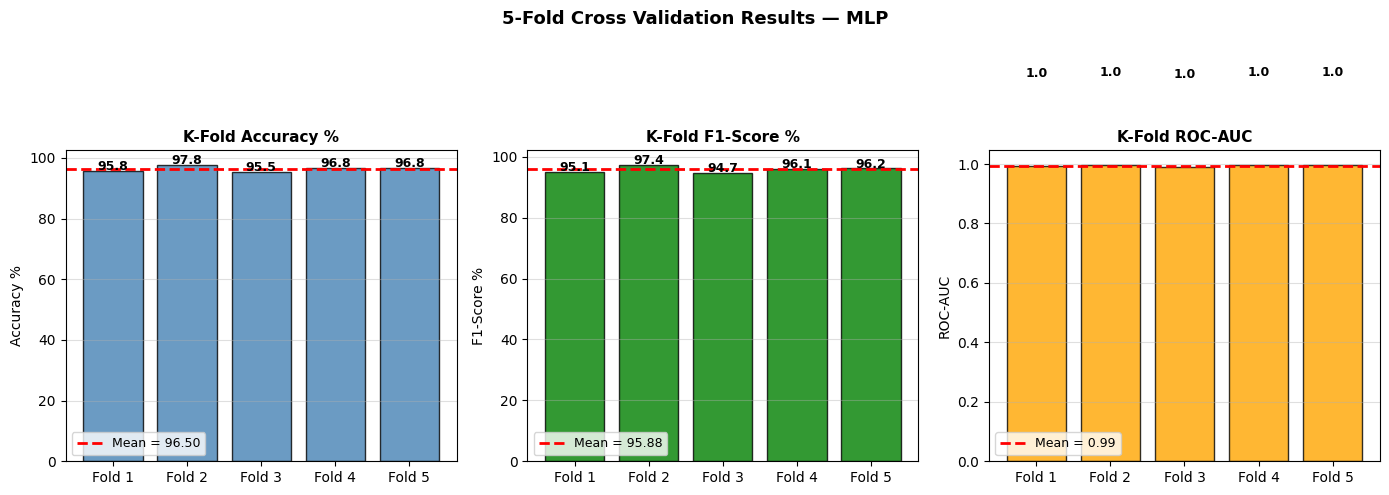

In [ ]:
# K-Fold results visualization
folds = [f'Fold {i+1}' for i in range(5)]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, vals, name, color in zip(
    axes,
    [[a*100 for a in fold_accs], [a*100 for a in fold_f1s], fold_aucs],
    ['Accuracy %', 'F1-Score %', 'ROC-AUC'],
    ['steelblue', 'green', 'orange']
):
    bars = ax.bar(folds, vals, color=color, edgecolor='black', alpha=0.8)

    ax.axhline(
        np.mean(vals),
        color='red',
        linestyle='--',
        linewidth=2,
        label=f'Mean = {np.mean(vals):.2f}'
    )

    ax.set_title(f'K-Fold {name}', fontsize=11, fontweight='bold')
    ax.set_ylabel(name)
    ax.legend(fontsize=9)
    ax.grid(True, axis='y', alpha=0.4)

    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{val:.1f}',
            ha='center',
            fontsize=9,
            fontweight='bold'
        )

plt.suptitle(
    '5-Fold Cross Validation Results — MLP',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

---
## Step 12 — Sample Patient Predictions

In [ ]:
# Show sample predictions

sample_probs = model.predict(X_test[:15], verbose=0).flatten()
sample_preds = (sample_probs > 0.5).astype(int)
sample_true  = y_test[:15].astype(int)

results = pd.DataFrame({
    'Patient'    : [f'P-{i+1}' for i in range(15)],
    'Probability': [round(p * 100, 1) for p in sample_probs],
    'Predicted'  : ['Blockage' if p == 1 else 'Normal' for p in sample_preds],
    'Actual'     : ['Blockage' if a == 1 else 'Normal' for a in sample_true],
    'Correct?'   : ['✓' if p == a else '✗'
                    for p, a in zip(sample_preds, sample_true)]
})

print('Sample Patient Predictions (First 15)')
print('=' * 60)

results

Sample Patient Predictions (First 15)


,Patient,Probability,Predicted,Actual,Correct?
0,P-1,98.500000,Blockage,Blockage,✓
1,P-2,7.000000,Normal,Normal,✓
2,P-3,0.000000,Normal,Normal,✓
3,P-4,0.000000,Normal,Normal,✓
4,P-5,0.000000,Normal,Normal,✓
5,P-6,100.000000,Blockage,Blockage,✓
6,P-7,100.000000,Blockage,Blockage,✓
7,P-8,100.000000,Blockage,Blockage,✓
8,P-9,100.000000,Blockage,Blockage,✓
9,P-10,100.000000,Blockage,Blockage,✓


---
## Step 13 — Save MLP Model

In [ ]:
import pickle

# Save complete TensorFlow model
model.save('phase3_mlp_model.keras')

# Save scaler
with open('phase3_mlp_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save results for Phase 6 (Ensemble)
mlp_results = {
    'name'        : 'MLP',
    'accuracy'    : acc,
    'precision'   : prec,
    'recall'      : rec,
    'f1'          : f1,
    'auc'         : auc,
    'y_prob_test' : y_prob,
    'y_test'      : y_test
}

with open('phase3_mlp_results.pkl', 'wb') as f:
    pickle.dump(mlp_results, f)

print('Files saved:')
print('  phase3_mlp_model.keras   ← TensorFlow Model')
print('  phase3_mlp_scaler.pkl    ← Scaler')
print('  phase3_mlp_results.pkl   ← Results for Ensemble (Phase 6)')

Files saved:
  phase3_mlp_model.keras   ← TensorFlow Model
  phase3_mlp_scaler.pkl    ← Scaler
  phase3_mlp_results.pkl   ← Results for Ensemble (Phase 6)


---
## Phase 3 Summary

In [ ]:
print('========================================')
print('  PHASE 3 — MLP COMPLETE')
print('========================================')
print('Architecture : 15 → 128 → 64 → 32 → 1')
print('Framework    : TensorFlow / Keras')
print('Optimizer    : Adam (lr=0.001)')
print('Loss         : Binary Cross Entropy')
print('Dropout      : 0.3, 0.2')
print('Early Stop   : Yes (patience=15)')
print('K-Fold CV    : 5-fold')
print('─────────────────────────────────')
print(f'Accuracy     : {acc*100:.2f}%')
print(f'Precision    : {prec*100:.2f}%')
print(f'Recall       : {rec*100:.2f}%')
print(f'F1-Score     : {f1*100:.2f}%')
print(f'ROC-AUC      : {auc:.4f}')
print('========================================')
print('  NEXT → PHASE 4: CNN + Attention')
print('========================================')

  PHASE 3 — MLP COMPLETE
Architecture : 15 → 128 → 64 → 32 → 1
Framework    : TensorFlow / Keras
Optimizer    : Adam (lr=0.001)
Loss         : Binary Cross Entropy
Dropout      : 0.3, 0.2
Early Stop   : Yes (patience=15)
K-Fold CV    : 5-fold
─────────────────────────────────
Accuracy     : 95.67%
Precision    : 95.24%
Recall       : 94.49%
F1-Score     : 94.86%
ROC-AUC      : 0.9944
  NEXT → PHASE 4: CNN + Attention
